In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df=pd.read_csv('dataset/breast-cancer.csv',usecols=['smoothness_mean','compactness_mean','concavity_mean','diagnosis'])
df

,diagnosis,smoothness_mean,compactness_mean,concavity_mean
0,M,0.11840,0.27760,0.30010
1,M,0.08474,0.07864,0.08690
2,M,0.10960,0.15990,0.19740
3,M,0.14250,0.28390,0.24140
4,M,0.10030,0.13280,0.19800
...,...,...,...,...
564,M,0.11100,0.11590,0.24390
565,M,0.09780,0.10340,0.14400
566,M,0.08455,0.10230,0.09251
567,M,0.11780,0.27700,0.35140


# Show  3d View  dataset

# 3d data

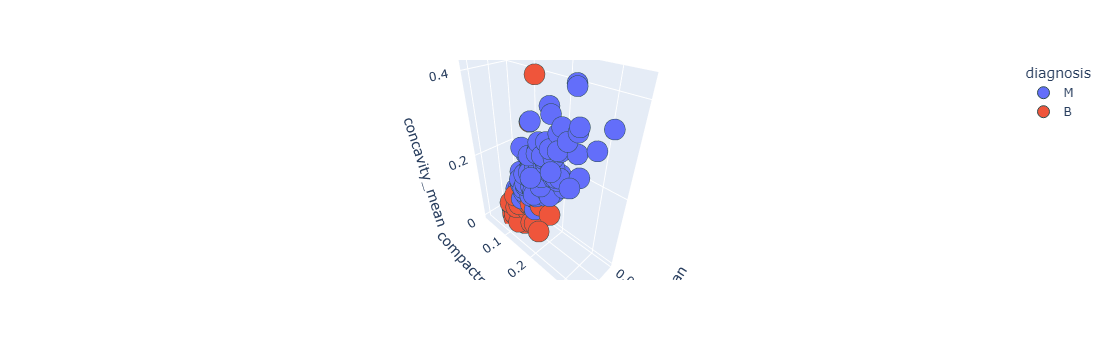

In [23]:
import plotly.express as px
fig=px.scatter_3d(df,x=df['smoothness_mean'],y=df['compactness_mean'],z=df['concavity_mean'],color=df['diagnosis'])
fig.update_traces(marker=dict(size=12,line=dict(width=1,color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

In [24]:
# Step 1 Apply StandardScaler
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df.iloc[:,1:]=scaler.fit_transform(df.iloc[:,1:])  # X features

In [25]:
# Step 2 - Find Covariance matrix
covariance_matrix=np.cov([df.iloc[:,1],df.iloc[:,2],df.iloc[:,3]])
print("Covariace_matrix :\n",covariance_matrix)

Covariace_matrix :
 [[1.00176056 0.66028364 0.52290275]
 [0.66028364 1.00176056 0.88467546]
 [0.52290275 0.88467546 1.00176056]]


In [26]:
# Step 3 Find Eigen values,Eigen vector 
eigen_values,eigen_vectors=np.linalg.eig(covariance_matrix)

In [27]:
eigen_values

array([2.39158102, 0.51506124, 0.09863943])

In [30]:
eigen_vectors

array([[ 0.51674649,  0.8357248 ,  0.18584165],
       [ 0.62078602, -0.21627518, -0.75355807],
       [ 0.58957423, -0.50476639,  0.63056572]])

In [31]:
pc=eigen_vectors[0:2]
pc

array([[ 0.51674649,  0.8357248 ,  0.18584165],
       [ 0.62078602, -0.21627518, -0.75355807]])

# 2 d data

In [32]:
transformed_df=np.dot(df.iloc[:,1:],pc.T)
new_df=pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['diagnosis']=df['diagnosis'].values
new_df.head()

,PC1,PC2,diagnosis
0,4.047629,-1.735555,M
1,-0.838819,-0.390056,M
2,1.620231,-0.670271,M
3,4.896714,-0.141320,M
4,0.850412,-0.975732,M


# Show 2d data represent 

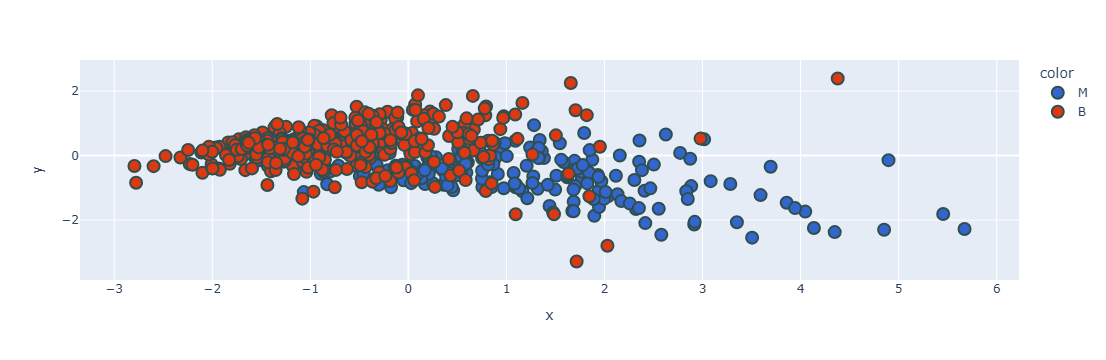

In [35]:
fig=px.scatter(x=new_df['PC1'],y=new_df['PC2'],color=new_df['diagnosis'],color_discrete_sequence=px.colors.qualitative.G10)
fig.update_traces(marker=dict(size=12,line=dict(width=2,color='DarkSlateGrey')),selector=dict(mode='markers'))
fig.show()